In [83]:
# Import libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Import utilities for data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import Machine Learning models for classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics for performance assessment
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Load the cybersecurity dataset into a pandas DataFrame
df = pd.read_csv("ai_ml_cybersecurity_dataset.csv")

# Display a preview of selected key features relevant to attack analysis
df[['Attack Type', 'Attack Severity', 'Data Exfiltrated', 'Response Action']].head()

,Attack Type,Attack Severity,Data Exfiltrated,Response Action
0,Ransomware,Critical,False,Eradicated
1,Malware,Critical,True,Eradicated
2,Ransomware,High,False,Eradicated
3,DDoS,Critical,False,Contained
4,Malware,Medium,False,Eradicated


In [85]:
# Remove rows with missing values to ensure data consistency
df = df.dropna()

# Display dataset structure, data types, and non-null counts after cleaning
df.info()

# Verify that no missing values remain in the dataset
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Event ID             20000 non-null  object
 1   Timestamp            20000 non-null  object
 2   Source IP            20000 non-null  object
 3   Destination IP       20000 non-null  object
 4   User Agent           20000 non-null  object
 5   Attack Type          20000 non-null  object
 6   Attack Severity      20000 non-null  object
 7   Data Exfiltrated     20000 non-null  bool  
 8   Threat Intelligence  20000 non-null  object
 9   Response Action      20000 non-null  object
dtypes: bool(1), object(9)
memory usage: 1.4+ MB


Event ID               0
Timestamp              0
Source IP              0
Destination IP         0
User Agent             0
Attack Type            0
Attack Severity        0
Data Exfiltrated       0
Threat Intelligence    0
Response Action        0
dtype: int64

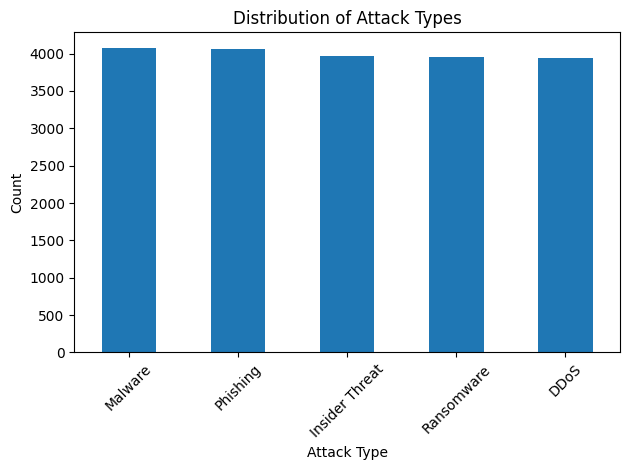

In [86]:
# Visualize the distribution of different cyber attack types
plt.figure()

# Plot frequency of each attack category as a bar chart
df['Attack Type'].value_counts().plot(kind='bar')

# Add title and axis labels for clarity
plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlap of labels
plt.tight_layout()

# Display the plot
plt.show()

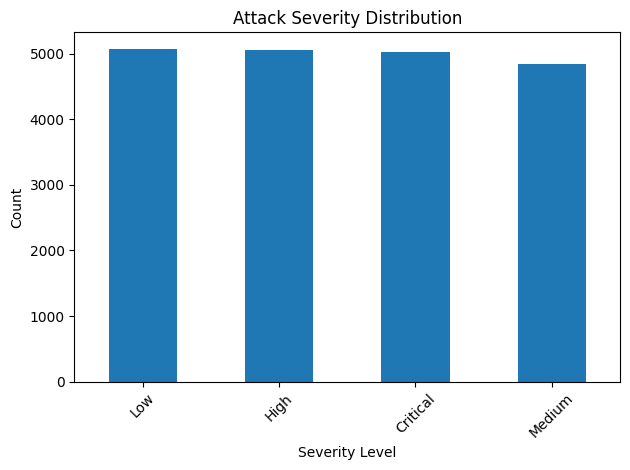

In [88]:
# Visualize the distribution of attack severity levels in the dataset
plt.figure()

# Plot the frequency of each severity category as a bar chart
df['Attack Severity'].value_counts().plot(kind='bar')

# Add title and axis labels for better interpretation
plt.title("Attack Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")

# Rotate x-axis labels to improve readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap of labels
plt.tight_layout()

# Display the visualization
plt.show()

In [89]:
# Remove non-informative and irrelevant features to reduce noise in the dataset
df = df.drop(columns=["Event ID","Timestamp", "Source IP", "Destination IP", "User Agent"], errors='ignore')

In [90]:
# Initialize a dictionary to store label encoders for each categorical feature
label_encoders = {}

# Iterate through all columns to identify categorical features
for column in df.columns:
    if df[column].dtype == 'object':

        # Apply label encoding to convert categorical values into numerical format
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

        # Store the encoder for potential inverse transformation or future use
        label_encoders[column] = le

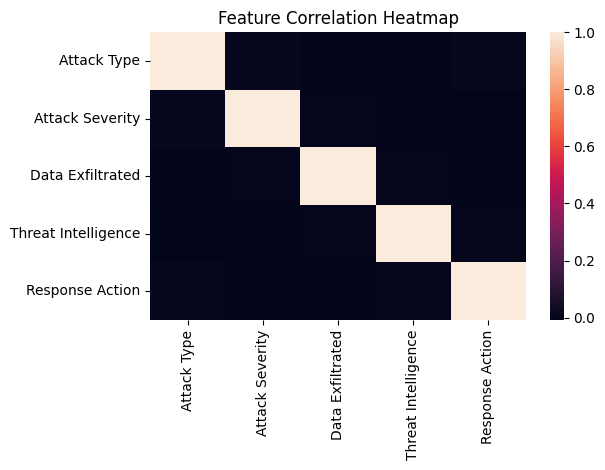

In [91]:
# Generate a correlation heatmap to analyze relationships between features
plt.figure()

# Compute and visualize the correlation matrix of the dataset
sns.heatmap(df.corr(), annot=False)

# Add title for contextual understanding
plt.title("Feature Correlation Heatmap")

# Adjust layout to ensure proper spacing of elements
plt.tight_layout()

# Display the heatmap
plt.show()

In [92]:
# Separate input features (X) and target variable (y) for classification
X = df.drop("Attack Type", axis=1)
y = df["Attack Type"]

In [93]:
# Split the dataset into training and testing sets for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 80% training data, 20% testing data to ensure unbiased evaluation

In [94]:
# Initialize Logistic Regression model with increased iterations for convergence
lr = LogisticRegression(max_iter=3000)

# Train the model using the training dataset
lr.fit(X_train, y_train)

# Generate predictions on the testing dataset
y_pred_lr = lr.predict(X_test)

In [95]:
# Initialize Random Forest classifier with multiple trees and controlled depth
rf = RandomForestClassifier(n_estimators=200, max_depth=10)

# Train the Random Forest model on the training dataset
rf.fit(X_train, y_train)

# Generate predictions on the testing dataset
y_pred_rf = rf.predict(X_test)

In [96]:
# Evaluate Logistic Regression model performance using accuracy metric
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Display detailed classification metrics (precision, recall, F1-score)
# zero_division=0 avoids undefined metric warnings for classes with no predictions
print(classification_report(y_test, y_pred_lr,zero_division=0))

Logistic Regression Accuracy: 0.19975
              precision    recall  f1-score   support

           0       0.18      0.22      0.20       776
           1       0.20      0.24      0.22       762
           2       0.23      0.28      0.25       816
           3       0.19      0.27      0.22       811
           4       0.00      0.00      0.00       835

    accuracy                           0.20      4000
   macro avg       0.16      0.20      0.18      4000
weighted avg       0.16      0.20      0.18      4000



In [97]:
# Evaluate Random Forest model performance using accuracy metric
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Display detailed classification metrics (precision, recall, F1-score)
# zero_division=0 ensures stable output for classes with no predicted samples
print(classification_report(y_test, y_pred_rf,zero_division=0))

Random Forest Accuracy: 0.199
              precision    recall  f1-score   support

           0       0.20      0.15      0.17       776
           1       0.18      0.24      0.21       762
           2       0.22      0.22      0.22       816
           3       0.19      0.24      0.21       811
           4       0.21      0.14      0.17       835

    accuracy                           0.20      4000
   macro avg       0.20      0.20      0.20      4000
weighted avg       0.20      0.20      0.20      4000



In [98]:
# Generate confusion matrix to evaluate classification performance across all classes
print(confusion_matrix(y_test, y_pred_rf))

[[116 196 153 206 105]
 [115 186 161 192 108]
 [117 212 183 191 113]
 [121 218 169 193 110]
 [107 212 175 223 118]]


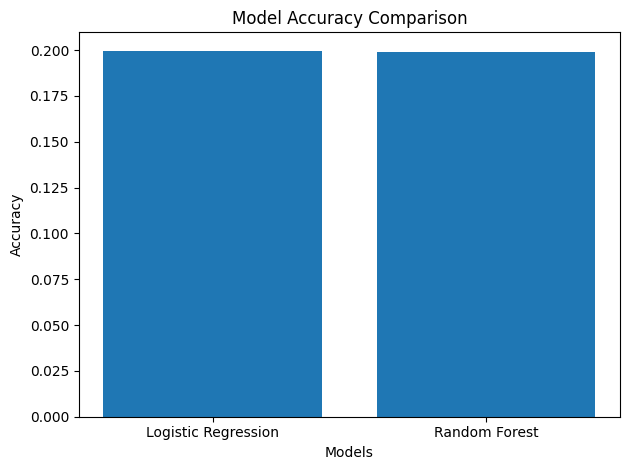

In [100]:
# Define model names for comparison
models = ['Logistic Regression', 'Random Forest']

# Compute accuracy scores for each model
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

# Visualize model performance comparison using a bar chart
plt.figure()
plt.bar(models, accuracies)

# Add title and axis labels for clarity
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Adjust layout for proper spacing
plt.tight_layout()

# Display the comparison plot
plt.show()

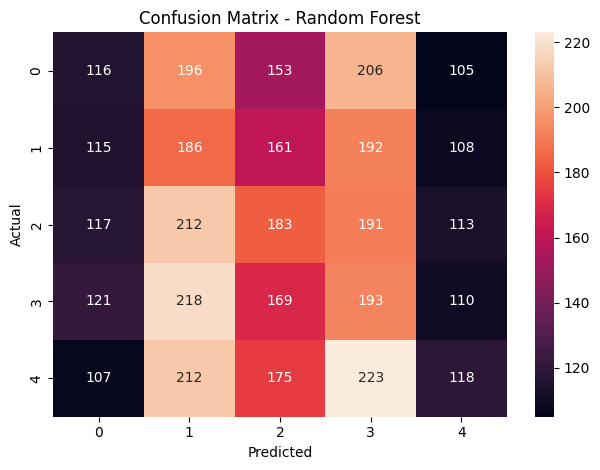

In [101]:
# Compute confusion matrix for the Random Forest model
cm = confusion_matrix(y_test, y_pred_rf)

# Visualize the confusion matrix using a heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

# Add title and axis labels for interpretability
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Adjust layout for better visualization
plt.tight_layout()

# Display the heatmap
plt.show()

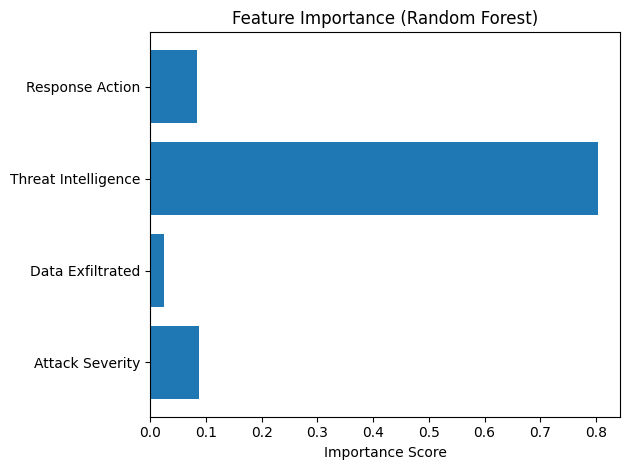

In [102]:
# Extract feature importance scores from the trained Random Forest model
importances = rf.feature_importances_

# Retrieve corresponding feature names
features = X.columns

# Visualize feature importance using a horizontal bar chart
plt.figure()
plt.barh(features, importances)

# Add title and axis label for clarity
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

# Adjust layout for better readability
plt.tight_layout()

# Display the feature importance plot
plt.show()